# Anomaly Detection

## 1. Load and check the data

In [1]:
import pandas as pd
p = pd.read_csv("../reports/final_dl_predictions.csv")
print(p.shape)
print(p.columns.tolist())
p.head(3)

C:\Users\94789\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(307058, 4)
['Datetime', 'Actual', 'Predicted', 'Residual']


,Datetime,Actual,Predicted,Residual
0,2010-04-18 18:06:00,1.044,1.101878,-0.057878
1,2010-04-18 18:07:00,0.480,1.003121,-0.523121
2,2010-04-18 18:08:00,0.312,0.419276,-0.107276


In [2]:
df = p.copy()
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime").sort_index()

print(df.index.min(), "->", df.index.max())
print(df.index.to_series().diff().value_counts().head())   # check for time gaps
print(df.isna().sum())
df.describe()

2010-04-18 18:06:00 -> 2010-11-26 21:02:00
Datetime
0 days 00:01:00    307055
5 days 03:15:00         1
3 days 18:06:00         1
Name: count, dtype: int64
Actual       0
Predicted    0
Residual     0
dtype: int64


,Actual,Predicted,Residual
count,307058.000000,307058.000000,307058.000000
mean,0.958221,0.970728,-0.012507
std,0.861651,0.838523,0.206786
min,0.138000,-0.077557,-3.601143
25%,0.320000,0.338634,-0.042279
50%,0.552000,0.577282,-0.019936
75%,1.432000,1.444131,0.007207
max,9.724000,9.865861,3.794229


## 2. Minute-level Expected vs Actual (first attempt)
Residual = Actual - Predicted. A global 3-sigma rule flags about 2.4% of minutes, which is far too many, so thresholds are compared, residual spread by consumption level is checked, and flagged minutes are grouped into events.

In [3]:
r = df["Residual"]
df["resid_z"] = (r - r.mean()) / r.std()
df["resid_anom"] = df["resid_z"].abs() > 3

print("Anomalies:", df["resid_anom"].sum(), f"({df['resid_anom'].mean()*100:.2f}%)")
df[df["resid_anom"]].sort_values("resid_z", key=abs, ascending=False).head(10)

Anomalies: 7404 (2.41%)


,Actual,Predicted,Residual,resid_z,resid_anom
Datetime,,,,,
2010-10-23 14:51:00,5.622,1.827771,3.794229,18.409046,True
2010-11-04 20:15:00,6.152,2.545065,3.606935,17.503310,True
2010-10-03 11:38:00,1.846,5.447143,-3.601143,-17.354333,True
2010-10-03 11:27:00,6.202,2.885271,3.316729,16.099895,True
2010-05-15 21:26:00,6.714,3.472692,3.241308,15.735168,True
2010-11-04 18:47:00,5.202,1.998513,3.203487,15.552267,True
2010-08-31 13:07:00,1.224,4.439761,-3.215761,-15.490658,True
2010-06-09 19:32:00,4.428,1.278785,3.149215,15.289813,True
2010-07-25 23:10:00,5.622,2.508800,3.113200,15.115648,True


In [4]:
import numpy as np
absr = df["Residual"].abs()
rows = []
for k in [2, 3, 4, 5, 6]:
    t = k * df["Residual"].std()
    rows.append((f"{k} sigma", round(t, 3), int((absr > t).sum()), round((absr > t).mean()*100, 2)))
for q in [0.99, 0.995, 0.999]:
    t = absr.quantile(q)
    rows.append((f"{q*100:.1f}th percentile", round(t, 3), int((absr > t).sum()), round((absr > t).mean()*100, 2)))

summary = pd.DataFrame(rows, columns=["rule", "threshold", "count", "percent"])
summary

,rule,threshold,count,percent
0,2 sigma,0.414,14767,4.81
1,3 sigma,0.620,7415,2.41
2,4 sigma,0.827,4473,1.46
3,5 sigma,1.034,2762,0.90
4,6 sigma,1.241,1746,0.57
5,99.0th percentile,0.991,3071,1.00
6,99.5th percentile,1.302,1536,0.50
7,99.9th percentile,1.961,308,0.10


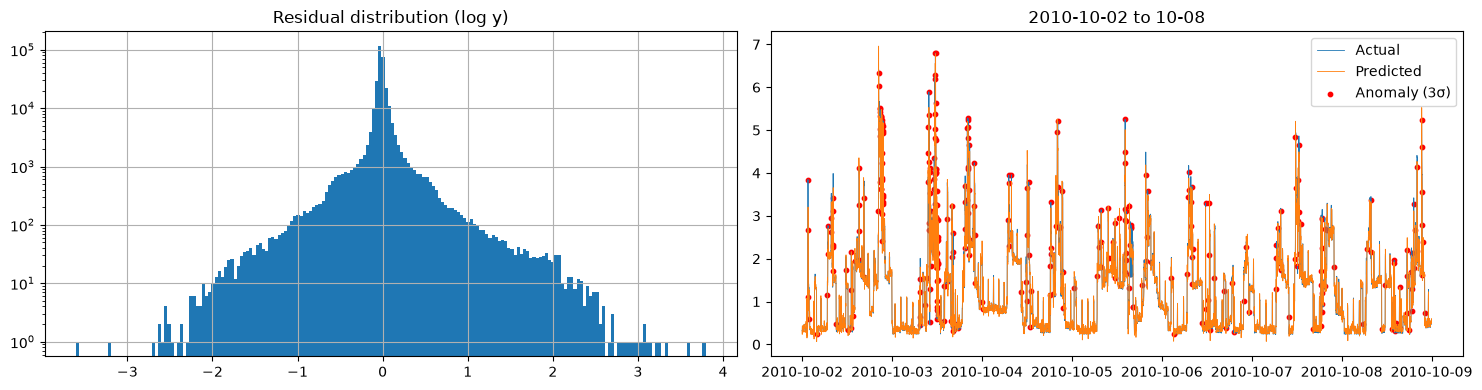

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(15, 4))

df["Residual"].hist(bins=200, ax=ax[0])
ax[0].set_yscale("log"); ax[0].set_title("Residual distribution (log y)")

week = df.loc["2010-10-02":"2010-10-08"]
ax[1].plot(week.index, week["Actual"], lw=0.6, label="Actual")
ax[1].plot(week.index, week["Predicted"], lw=0.6, label="Predicted")
a = week[week["resid_anom"]]
ax[1].scatter(a.index, a["Actual"], color="red", s=10, label="Anomaly (3σ)")
ax[1].legend(); ax[1].set_title("2010-10-02 to 10-08")
plt.tight_layout(); plt.show()

In [6]:
gaps = df.index.to_series().diff()
gaps[gaps > pd.Timedelta("1h")]

Datetime
2010-08-23 00:16:00   5 days 03:15:00
2010-09-28 22:01:00   3 days 18:06:00
Name: Datetime, dtype: timedelta64[us]

In [7]:
df["level"] = pd.qcut(df["Predicted"], 5, duplicates="drop")
df.groupby("level", observed=True)["Residual"].agg(
    count="size", std="std", p99=lambda x: x.abs().quantile(0.99)
)

,count,std,p99
level,,,
"(-0.0786, 0.309]",61412,0.075253,0.293617
"(0.309, 0.425]",61411,0.088509,0.405267
"(0.425, 0.991]",61412,0.172131,0.662010
"(0.991, 1.541]",61411,0.182953,0.875895
"(1.541, 9.866]",61412,0.370338,1.593167


In [8]:
s = df.groupby("level", observed=True)["Residual"].transform("std")
df["z_level"] = df["Residual"] / s
df["anom_level"] = df["z_level"].abs() > 4

def make_events(flag, gap_min=5):
    t = flag[flag].index.to_series()
    ev = (t.diff() > pd.Timedelta(minutes=gap_min)).cumsum()
    return t.groupby(ev).agg(start="min", end="max", minutes="count")

events = make_events(df["anom_level"])
print("Flagged minutes:", df["anom_level"].sum(), "| events:", len(events))
print(events["minutes"].describe())
events.sort_values("minutes", ascending=False).head(10)

Flagged minutes: 3592 | events: 3029
count    3029.000000
mean        1.185870
std         0.841139
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        26.000000
Name: minutes, dtype: float64


,start,end,minutes
Datetime,,,
2410,2010-10-03 11:16:00,2010-10-03 12:16:00,26
2901,2010-11-14 12:04:00,2010-11-14 12:41:00,17
648,2010-06-06 12:51:00,2010-06-06 13:21:00,16
638,2010-06-06 01:03:00,2010-06-06 01:26:00,11
2803,2010-11-04 20:53:00,2010-11-04 21:20:00,10
631,2010-06-05 23:20:00,2010-06-05 23:39:00,9
2009,2010-09-05 15:31:00,2010-09-05 15:49:00,7
2310,2010-09-22 19:03:00,2010-09-22 19:16:00,7
2309,2010-09-22 18:40:00,2010-09-22 18:55:00,7


In [9]:
d = df.loc[df["anom_level"], ["z_level", "Residual", "Actual", "Predicted"]].copy()
d["event_id"] = (d.index.to_series().diff() > pd.Timedelta(minutes=5)).cumsum()
d = d.reset_index()

events = d.groupby("event_id").agg(
    start=("Datetime", "min"), end=("Datetime", "max"),
    minutes=("Datetime", "count"),
    max_abs_z=("z_level", lambda x: x.abs().max()),
    mean_resid=("Residual", "mean"),
    peak_actual=("Actual", "max"),
)
events["direction"] = np.where(events["mean_resid"] > 0, "higher than expected", "lower than expected")

days = df.index.normalize().nunique()
rules = {
    "all events": events,
    "minutes >= 3": events[events.minutes >= 3],
    "max|z| >= 8": events[events.max_abs_z >= 8],
    "minutes >= 3 OR max|z| >= 8": events[(events.minutes >= 3) | (events.max_abs_z >= 8)],
}
pd.DataFrame(
    {k: [len(v), round(len(v) / days, 2)] for k, v in rules.items()},
    index=["events", "per day"],
).T

,events,per day
all events,3029.0,14.02
minutes >= 3,93.0,0.43
max|z| >= 8,507.0,2.35
minutes >= 3 OR max|z| >= 8,555.0,2.57


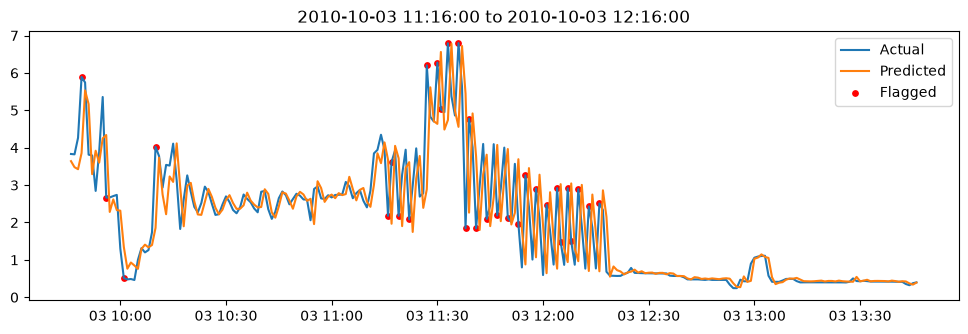

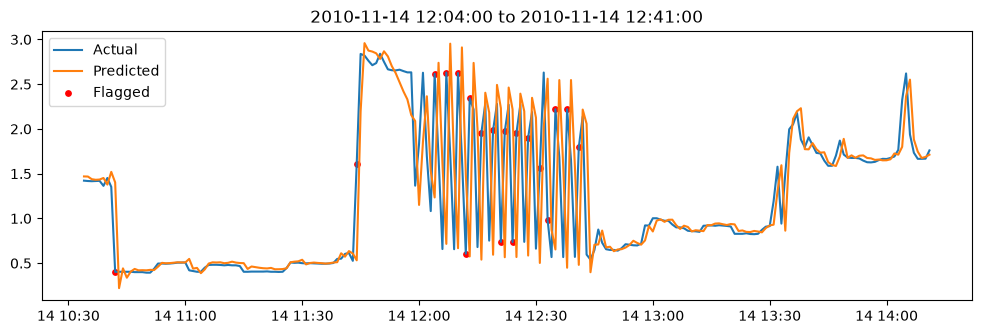

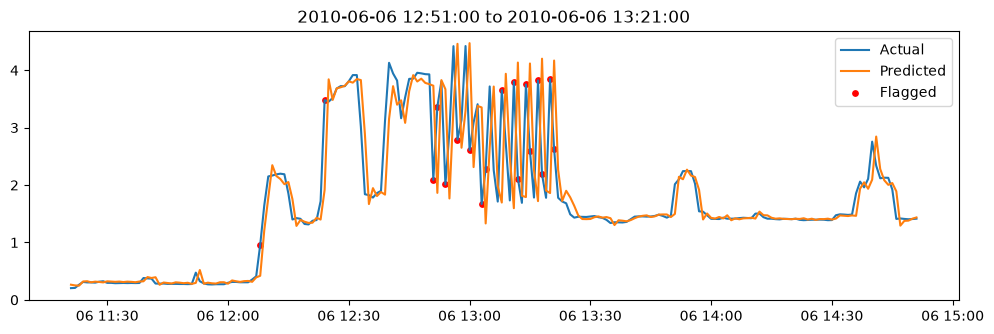

In [10]:
def plot_event(start, end, pad="90min"):
    w = df.loc[pd.Timestamp(start) - pd.Timedelta(pad): pd.Timestamp(end) + pd.Timedelta(pad)]
    plt.figure(figsize=(12, 3.5))
    plt.plot(w.index, w["Actual"], label="Actual")
    plt.plot(w.index, w["Predicted"], label="Predicted")
    a = w[w["anom_level"]]
    plt.scatter(a.index, a["Actual"], color="red", s=15, label="Flagged")
    plt.legend(); plt.title(f"{start} to {end}"); plt.show()

for _, r in events.sort_values("minutes", ascending=False).head(3).iterrows():
    plot_event(r["start"], r["end"])

### Is the forecast a lag copy?
The forecast correlates 0.996 with the previous minute's actual value, and the longest flagged events alternate above/below the forecast (rapid appliance on/off cycling). Minute-level residuals therefore mostly show forecast lag, so they are not used as a stand-alone detector. Detection continues on hourly means.

In [11]:
print("corr(Pred, Actual):        ", df["Predicted"].corr(df["Actual"]))
print("corr(Pred, Actual 1min ago):", df["Predicted"].corr(df["Actual"].shift(1)))

def flip_rate(start, end):
    s = np.sign(df.loc[start:end, "Residual"].values)
    return (s[1:] != s[:-1]).mean() if len(s) > 1 else np.nan

events["flip_rate"] = [flip_rate(a, b) for a, b in zip(events["start"], events["end"])]
big = events[events.minutes >= 3].copy()
big["type"] = np.where(big["flip_rate"] >= 0.6, "cycling (forecast lag)", "sustained deviation")
print(big["type"].value_counts())
big.sort_values("minutes", ascending=False).head(10)

corr(Pred, Actual):         0.9707786646530586
corr(Pred, Actual 1min ago): 0.9961414321401212
type
cycling (forecast lag)    53
sustained deviation       40
Name: count, dtype: int64


,start,end,minutes,max_abs_z,mean_resid,peak_actual,direction,flip_rate,type
event_id,,,,,,,,,
2410,2010-10-03 11:16:00,2010-10-03 12:16:00,26,13.828484,0.275852,6.796,higher than expected,0.650000,cycling (forecast lag)
2901,2010-11-14 12:04:00,2010-11-14 12:41:00,17,11.368883,0.836136,2.630,higher than expected,0.648649,cycling (forecast lag)
648,2010-06-06 12:51:00,2010-06-06 13:21:00,16,5.960432,-0.183872,3.850,lower than expected,0.666667,cycling (forecast lag)
638,2010-06-06 01:03:00,2010-06-06 01:26:00,11,13.153018,0.746086,3.664,higher than expected,0.608696,cycling (forecast lag)
2803,2010-11-04 20:53:00,2010-11-04 21:20:00,10,6.808203,1.973146,4.814,higher than expected,0.666667,cycling (forecast lag)
631,2010-06-05 23:20:00,2010-06-05 23:39:00,9,13.508399,1.179686,5.246,higher than expected,0.631579,cycling (forecast lag)
2009,2010-09-05 15:31:00,2010-09-05 15:49:00,7,5.984253,-0.255935,1.984,lower than expected,0.500000,sustained deviation
2309,2010-09-22 18:40:00,2010-09-22 18:55:00,7,10.782813,0.795468,2.532,higher than expected,0.600000,cycling (forecast lag)
2310,2010-09-22 19:03:00,2010-09-22 19:16:00,7,9.059171,0.458830,3.744,higher than expected,0.615385,cycling (forecast lag)


## 3. Hourly analysis: normal consumption patterns

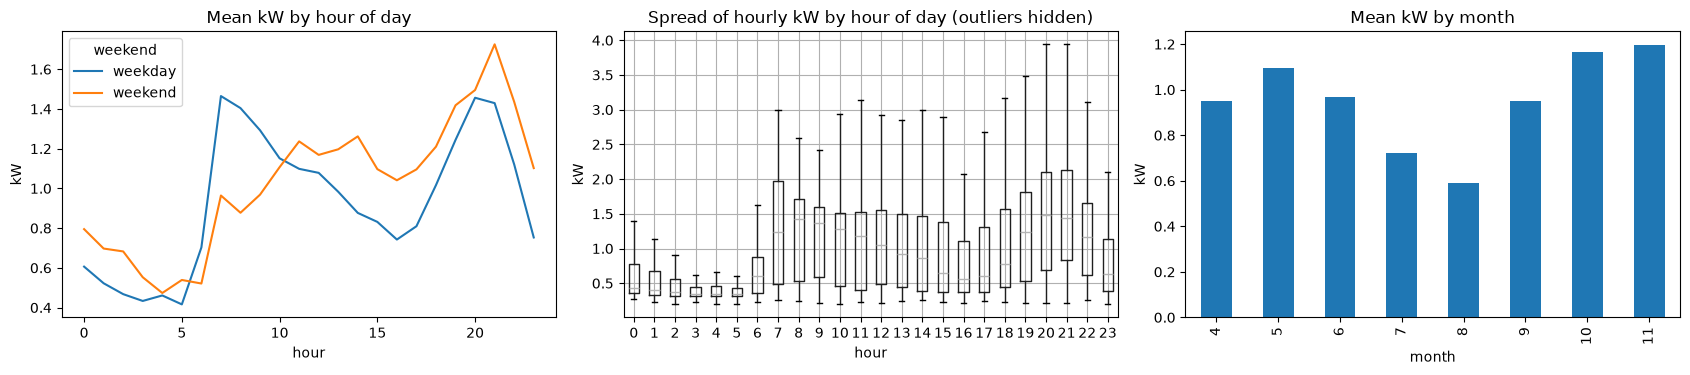

In [12]:
# Normal consumption patterns (hourly means)
prof = df["Actual"].resample("1h").mean().dropna().to_frame("kw")
prof["hour"] = prof.index.hour
prof["weekend"] = prof.index.dayofweek >= 5
prof["month"] = prof.index.month

fig, ax = plt.subplots(1, 3, figsize=(17, 4))

prof.groupby(["weekend", "hour"])["kw"].mean().unstack(0).rename(
    columns={False: "weekday", True: "weekend"}).plot(ax=ax[0], title="Mean kW by hour of day")
ax[0].set_ylabel("kW")

prof.boxplot(column="kw", by="hour", ax=ax[1], showfliers=False)
ax[1].set_title("Spread of hourly kW by hour of day (outliers hidden)")
ax[1].set_xlabel("hour"); ax[1].set_ylabel("kW")
plt.suptitle("")

prof.groupby("month")["kw"].mean().plot.bar(ax=ax[2], title="Mean kW by month")
ax[2].set_ylabel("kW")
plt.tight_layout(); plt.show()

### Global Z-score and IQR (baselines)
Z-score and IQR computed per (weekday/weekend, hour of day) over the whole period. These are kept as comparison baselines; section 5 explains why a rolling baseline is preferred.

In [13]:
h = df["Actual"].resample("1h").mean().dropna().to_frame("kw")
h["hour"] = h.index.hour
h["weekend"] = h.index.dayofweek >= 5
g = h.groupby(["weekend", "hour"])["kw"]

h["z"] = (h["kw"] - g.transform("mean")) / g.transform("std")
q1 = g.transform(lambda x: x.quantile(0.25))
q3 = g.transform(lambda x: x.quantile(0.75))
iqr = q3 - q1
h["z_anom"] = h["z"].abs() > 3
h["iqr_anom"] = (h["kw"] < q1 - 1.5 * iqr) | (h["kw"] > q3 + 1.5 * iqr)

print("hours:", len(h))
print("Z-score anomalies:", h["z_anom"].sum(), "| IQR anomalies:", h["iqr_anom"].sum())
print("Both:", (h["z_anom"] & h["iqr_anom"]).sum())
h[h["z_anom"] | h["iqr_anom"]].sort_values("z", key=abs, ascending=False).head(10)

hours: 5120
Z-score anomalies: 66 | IQR anomalies: 212
Both: 64


,kw,hour,weekend,z,z_anom,iqr_anom
Datetime,,,,,,
2010-07-01 00:00:00,3.329033,0,False,5.853629,True,True
2010-10-31 05:00:00,2.910300,5,True,5.144514,True,True
2010-07-22 01:00:00,2.168033,1,False,5.110933,True,True
2010-07-02 03:00:00,1.612200,3,False,4.927275,True,True
2010-11-04 08:00:00,4.418900,8,False,4.775451,True,True
2010-07-14 23:00:00,3.129100,23,False,4.759283,True,True
2010-11-20 18:00:00,5.626833,18,True,4.519801,True,True
2010-07-22 00:00:00,2.674933,0,False,4.447425,True,True
2010-09-17 16:00:00,2.964167,16,False,4.439860,True,True


## 4. Hourly Expected vs Actual (residual)
Robust z-score of the hourly residual (median/MAD). `K = 4` here is exploratory; the final rule uses `K = 6` (about 0.10 kW) so tiny deviations are not reported.

In [14]:
hh = df[["Actual", "Predicted"]].resample("1h").mean().dropna()
hh["resid"] = hh["Actual"] - hh["Predicted"]
hh["hour"] = hh.index.hour

med = hh["resid"].median()
mad = (hh["resid"] - med).abs().median() * 1.4826
hh["resid_rz"] = (hh["resid"] - med) / mad
for k in [3, 4, 5, 6]:
    print(f"|robust z| > {k}:", int((hh["resid_rz"].abs() > k).sum()))

K = 4   # exploratory value only; the final rule (section 7) uses K = 6
hh["resid_anom"] = hh["resid_rz"].abs() > K
hh["z_anom"] = h["z_anom"]
hh["iqr_anom"] = h["iqr_anom"]
hh["n_methods"] = hh[["z_anom", "iqr_anom", "resid_anom"]].sum(axis=1)

print(hh["n_methods"].value_counts().sort_index())
hh[hh["n_methods"] >= 2].sort_values("n_methods", ascending=False).head(15)

|robust z| > 3: 308
|robust z| > 4: 168
|robust z| > 5: 97
|robust z| > 6: 66
n_methods
0    4774
1     276
2      40
3      30
Name: count, dtype: int64


,Actual,Predicted,resid,hour,resid_rz,resid_anom,z_anom,iqr_anom,n_methods
Datetime,,,,,,,,,
2010-04-19 17:00:00,2.682733,2.627612,0.055122,17,4.215092,True,True,True,3
2010-04-25 01:00:00,2.761133,2.669259,0.091874,1,6.357719,True,True,True,3
2010-05-02 13:00:00,3.525233,3.458757,0.066476,13,4.877037,True,True,True,3
2010-06-23 21:00:00,3.941100,3.722239,0.218861,21,13.760912,True,True,True,3
2010-05-15 23:00:00,3.819833,3.757470,0.062363,23,4.637256,True,True,True,3
2010-05-12 14:00:00,2.985533,2.918233,0.067301,14,4.925119,True,True,True,3
2010-11-04 10:00:00,3.626633,3.528639,0.097994,10,6.714498,True,True,True,3
2010-11-04 08:00:00,4.418900,4.217779,0.201121,8,12.726699,True,True,True,3
2010-11-04 20:00:00,4.462600,3.987911,0.474689,20,28.675432,True,True,True,3


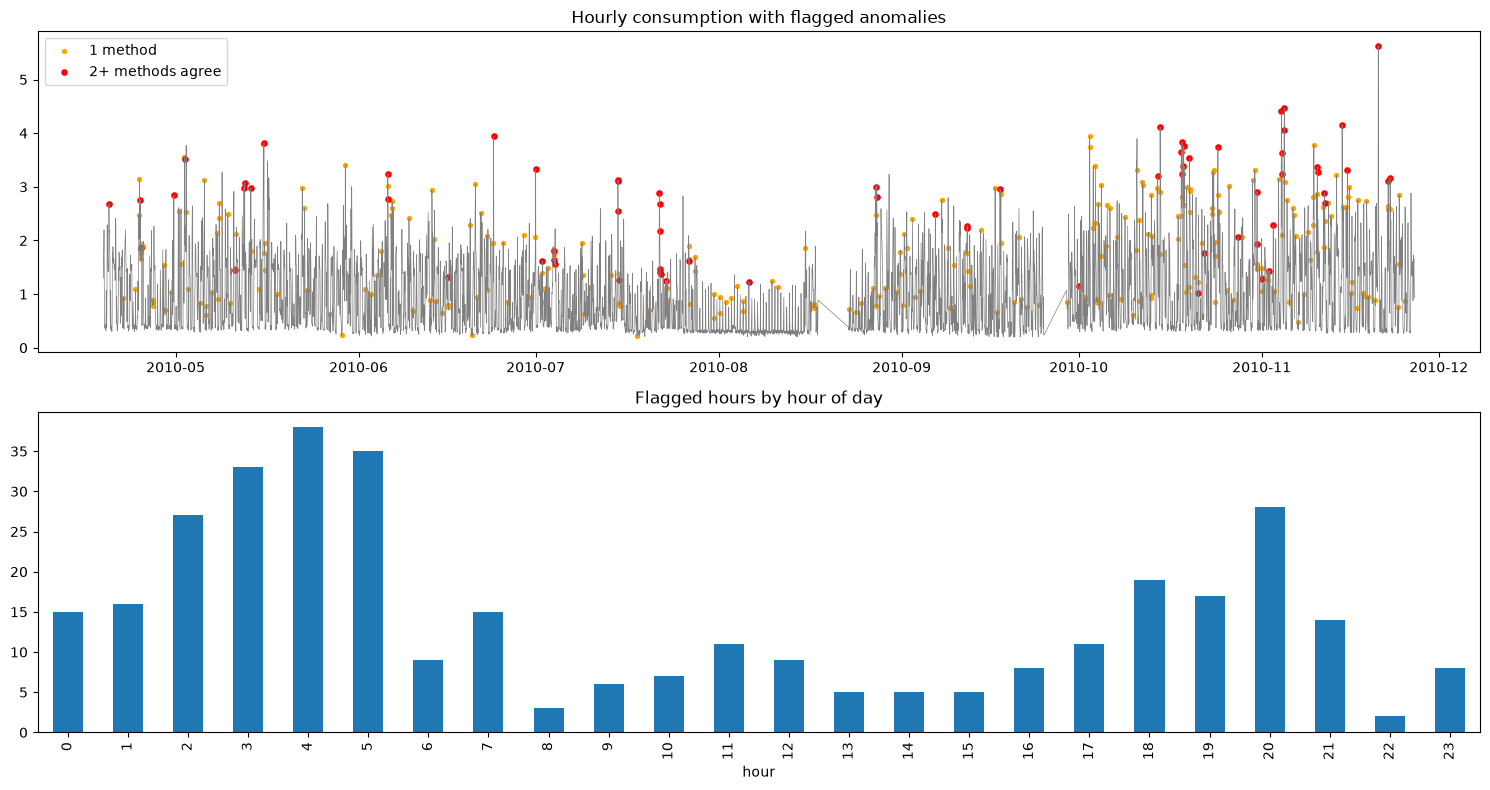

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
ax[0].plot(hh.index, hh["Actual"], lw=0.5, color="gray")
b = hh[hh["n_methods"] == 1]
a = hh[hh["n_methods"] >= 2]
ax[0].scatter(b.index, b["Actual"], color="orange", s=8, label="1 method")
ax[0].scatter(a.index, a["Actual"], color="red", s=14, label="2+ methods agree")
ax[0].legend(); ax[0].set_title("Hourly consumption with flagged anomalies")

hh[hh["n_methods"] >= 1].groupby("hour").size().reindex(range(24), fill_value=0).plot.bar(ax=ax[1])
ax[1].set_title("Flagged hours by hour of day")
plt.tight_layout(); plt.show()

In [16]:
print("median resid:", round(med, 4), "| MAD (kW):", round(mad, 4))
for k in [4, 5, 6, 8]:
    print(f"K={k}: flags if |resid - median| > {k*mad:.3f} kW")

hh["month"] = hh.index.month
hh.groupby("month").agg(
    hours=("Actual", "size"),
    mean_kw=("Actual", "mean"),
    flagged_1plus=("n_methods", lambda x: int((x >= 1).sum())),
    flagged_2plus=("n_methods", lambda x: int((x >= 2).sum())),
)

median resid: -0.0172 | MAD (kW): 0.0172
K=4: flags if |resid - median| > 0.069 kW
K=5: flags if |resid - median| > 0.086 kW
K=6: flags if |resid - median| > 0.103 kW
K=8: flags if |resid - median| > 0.137 kW


,hours,mean_kw,flagged_1plus,flagged_2plus
month,,,,
4,294,0.950413,19,4
5,744,1.095298,38,6
6,720,0.969630,35,4
7,744,0.721111,45,17
8,622,0.591201,28,3
9,630,0.951388,30,4
10,744,1.163412,85,15
11,622,1.196454,66,17


## 5. Rolling Z-score (main method)
Compares each hour with the same hour over the previous 28 days (at least 14 days needed, so the first two weeks have no score). This removes the night-time bias and the seasonal level effect of the global Z-score.

Rolling Z anomalies: 114 | old global Z: 66
Overlap: 32


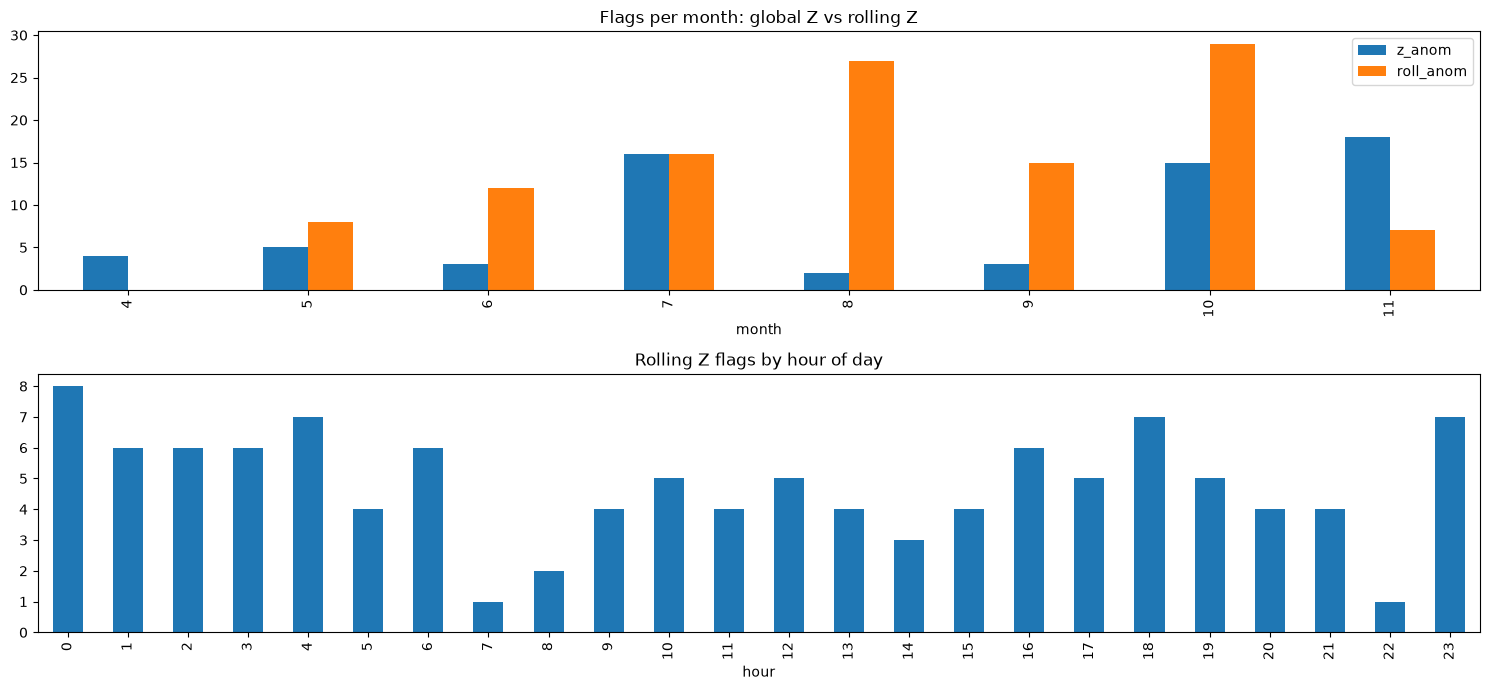

In [17]:
def rolling_z(s, win=28, minp=14):
    grp = s.groupby(s.index.hour)
    m  = grp.transform(lambda x: x.rolling(win, min_periods=minp).mean().shift(1))
    sd = grp.transform(lambda x: x.rolling(win, min_periods=minp).std().shift(1))
    return (s - m) / sd

hh["z_roll"] = rolling_z(hh["Actual"])
hh["roll_anom"] = hh["z_roll"].abs() > 3

print("Rolling Z anomalies:", int(hh["roll_anom"].sum()), "| old global Z:", int(hh["z_anom"].sum()))
print("Overlap:", int((hh["roll_anom"] & hh["z_anom"]).sum()))

fig, ax = plt.subplots(2, 1, figsize=(15, 7))
hh.groupby("month")[["z_anom", "roll_anom"]].sum().plot.bar(ax=ax[0])
ax[0].set_title("Flags per month: global Z vs rolling Z")
hh[hh["roll_anom"]].groupby("hour").size().reindex(range(24), fill_value=0).plot.bar(ax=ax[1])
ax[1].set_title("Rolling Z flags by hour of day")
plt.tight_layout(); plt.show()

In [18]:
x = hh[hh["roll_anom"]].copy()
x["dir"] = np.where(x["z_roll"] > 0, "high", "low")
print(x.groupby(["month", "dir"]).size().unstack(fill_value=0))
x.loc[x["month"].isin([8, 10]), ["Actual", "z_roll", "dir"]].sort_values("z_roll", key=abs, ascending=False).head(15)

dir    high  low
month           
5         8    0
6        12    0
7        16    0
8        27    0
9        15    0
10       28    1
11        7    0


,Actual,z_roll,dir
Datetime,,,
2010-10-31 05:00:00,2.910300,12.423784,high
2010-08-27 14:00:00,2.996567,11.291369,high
2010-08-27 19:00:00,3.052667,10.666441,high
2010-08-27 15:00:00,2.477133,9.380180,high
2010-10-24 02:00:00,1.970400,8.160488,high
2010-08-15 18:00:00,2.176700,7.287358,high
2010-10-24 03:00:00,1.704433,5.908223,high
2010-10-23 17:00:00,3.270733,5.776559,high
2010-10-31 04:00:00,1.466500,5.758623,high


## 6. Isolation Forest (main method)
Features: kW, hour of day (sin/cos), weekend flag, 1-hour difference, 24-hour rolling mean and the deviation from it. Contamination 0.5% / 1% / 2% flags 26 / 52 / 103 hours (set by the parameter); 1% is used.

In [19]:
from sklearn.ensemble import IsolationForest

f = pd.DataFrame(index=hh.index)
f["kw"] = hh["Actual"]
f["hour_sin"] = np.sin(2 * np.pi * hh.index.hour / 24)
f["hour_cos"] = np.cos(2 * np.pi * hh.index.hour / 24)
f["weekend"] = (hh.index.dayofweek >= 5).astype(int)
f["diff_1h"] = hh["Actual"].diff()
f["roll24_mean"] = hh["Actual"].rolling(24, min_periods=12).mean()
f["dev_from_24h"] = hh["Actual"] - f["roll24_mean"]
f = f.dropna()
feats = f.columns.tolist()

for c in [0.005, 0.01, 0.02]:
    lab = IsolationForest(n_estimators=300, contamination=c, random_state=42).fit_predict(f[feats])
    print(f"contamination={c}: {(lab == -1).sum()} flagged")

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=42).fit(f[feats])
hh["iso_score"] = np.nan
hh.loc[f.index, "iso_score"] = iso.decision_function(f[feats])
hh["iso_anom"] = False
hh.loc[f.index, "iso_anom"] = iso.predict(f[feats]) == -1

print("IF flagged:", int(hh["iso_anom"].sum()))
print("overlap with rolling Z:", int((hh["iso_anom"] & hh["roll_anom"]).sum()))
print("overlap with global Z: ", int((hh["iso_anom"] & hh["z_anom"]).sum()))
hh.groupby("month")["iso_anom"].sum()

contamination=0.005: 26 flagged
contamination=0.01: 52 flagged
contamination=0.02: 103 flagged
IF flagged: 52
overlap with rolling Z: 23
overlap with global Z:  23


month
4      1
5     10
6      3
7      3
8      0
9      0
10    21
11    14
Name: iso_anom, dtype: int64

## 7. Final rule: ensemble and severity
Three main methods (rolling Z, Isolation Forest, residual with K = 6). **high** = 3 agree, **medium** = 2 agree (both reported as anomalies), **low** = 1 method (watch-list). The methods use overlapping information, so agreement means higher confidence, not independent proof.

In [20]:
hh["resid_anom"] = hh["resid_rz"].abs() > 6
hh["n_main"] = hh[["roll_anom", "iso_anom", "resid_anom"]].sum(axis=1)
hh["severity"] = hh["n_main"].map({0: "none", 1: "low", 2: "medium", 3: "high"})

print(hh["severity"].value_counts())
print(hh.groupby("month")["n_main"].apply(lambda x: int((x >= 2).sum())))

cols = ["Actual", "Predicted", "resid", "z_roll", "iso_score", "roll_anom", "iso_anom", "resid_anom", "n_main"]
hh[hh["n_main"] >= 2].assign(az=hh["z_roll"].abs()).sort_values(["n_main", "az"], ascending=False)[cols].head(20)

severity
none      4946
low        132
medium      26
high        16
Name: count, dtype: int64
month
4      0
5      7
6      5
7      1
8      1
9      1
10    16
11    11
Name: n_main, dtype: int64


,Actual,Predicted,resid,z_roll,iso_score,roll_anom,iso_anom,resid_anom,n_main
Datetime,,,,,,,,,
2010-10-31 05:00:00,2.910300,2.808788,0.101512,12.423784,-0.022018,True,True,True,3
2010-11-20 18:00:00,5.626833,5.466652,0.160181,5.541047,-0.063158,True,True,True,3
2010-07-01 00:00:00,3.329033,3.208150,0.120883,4.795726,-0.004881,True,True,True,3
2010-11-04 08:00:00,4.418900,4.217779,0.201121,4.466770,-0.043212,True,True,True,3
2010-06-23 21:00:00,3.941100,3.722239,0.218861,4.357595,-0.035886,True,True,True,3
2010-05-29 18:00:00,3.412000,3.320103,0.091897,4.298844,-0.031036,True,True,True,3
2010-06-13 10:00:00,2.933267,2.812947,0.120320,4.296648,-0.019936,True,True,True,3
2010-10-18 18:00:00,3.391467,3.175419,0.216048,4.222582,-0.039788,True,True,True,3
2010-11-14 15:00:00,4.156567,3.789079,0.367488,3.898249,-0.064845,True,True,True,3


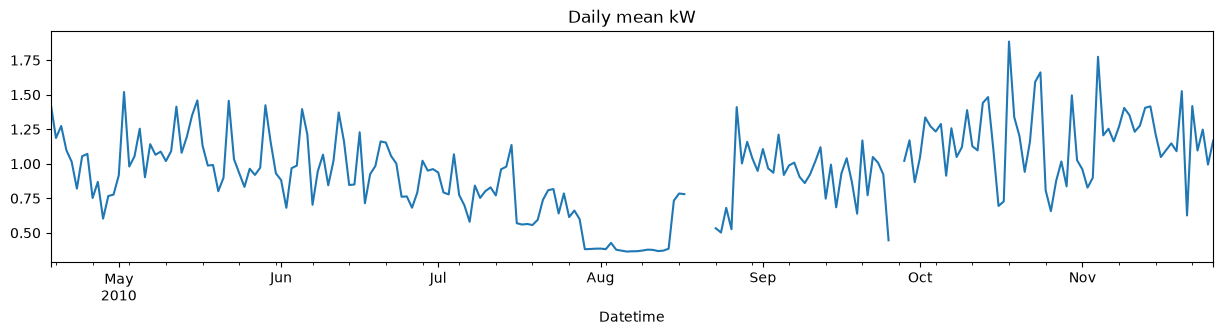

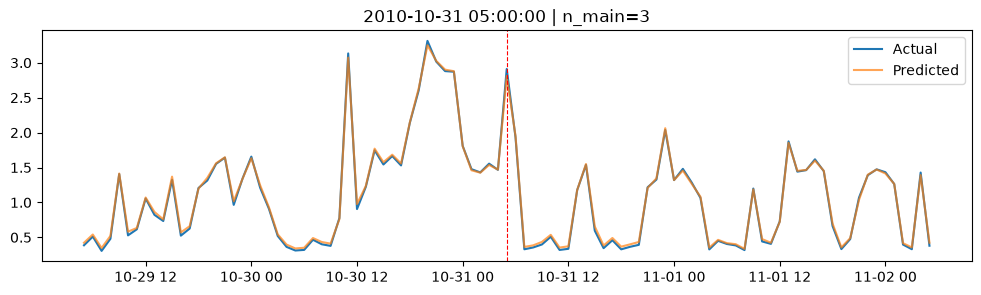

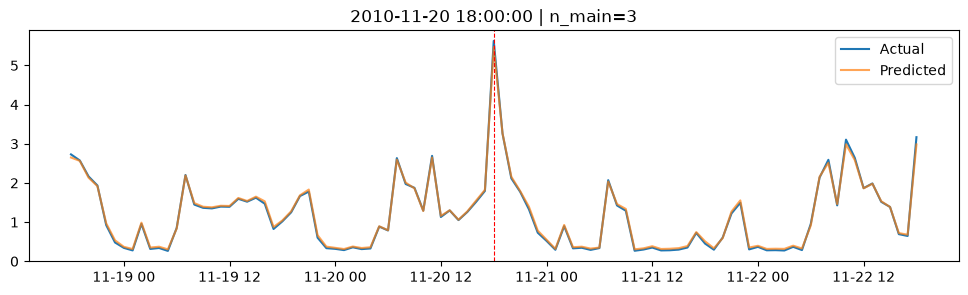

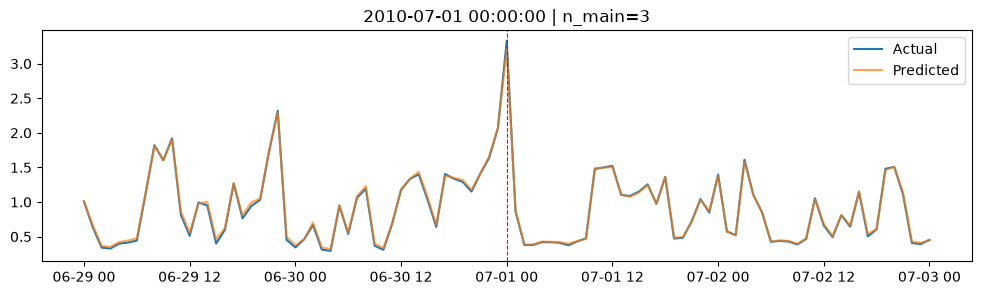

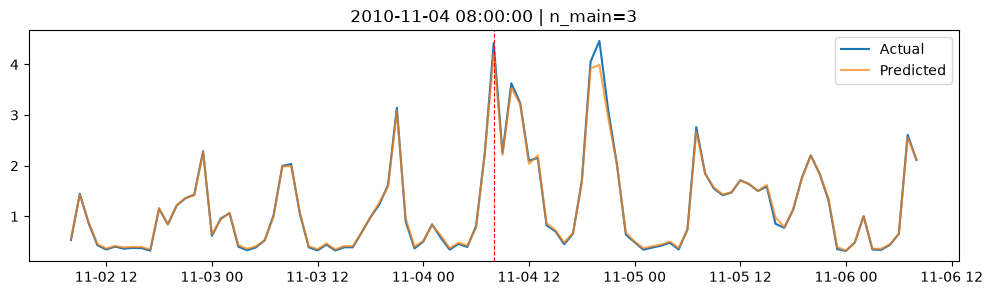

In [21]:
hh["Actual"].resample("D").mean().plot(figsize=(15, 3), title="Daily mean kW")
plt.show()

def plot_hours(ts, pad="2D"):
    ts = pd.Timestamp(ts)
    w = hh.loc[ts - pd.Timedelta(pad): ts + pd.Timedelta(pad)]
    plt.figure(figsize=(12, 3))
    plt.plot(w.index, w["Actual"], label="Actual")
    plt.plot(w.index, w["Predicted"], label="Predicted", alpha=0.7)
    plt.axvline(ts, color="red", ls="--", lw=0.8)
    plt.title(f"{ts} | n_main={int(hh.loc[ts, 'n_main'])}")
    plt.legend(); plt.show()

top = hh[hh["n_main"] >= 2].assign(az=hh["z_roll"].abs()).sort_values(["n_main", "az"], ascending=False).head(4)
for ts in top.index:
    plot_hours(ts)

## 8. Evaluation with synthetic anomalies
No labelled anomalies exist. Synthetic spikes and drops are injected into hours that no method flagged, then recall is measured. Precision cannot be measured this way. The injection sizes are our own choice, so this is a sanity check, not a real accuracy figure. `follow` in the sweep is the share of a spike that the forecast also reproduces (0 = best case for the residual method, 0.95 = assumed realistic case).

In [22]:
from sklearn.ensemble import IsolationForest

def detect(actual, predicted, contamination=0.01, z_thr=3, k_resid=6, seed=42):
    d = pd.DataFrame({"Actual": actual, "Predicted": predicted})
    d["roll_anom"] = rolling_z(d["Actual"]).abs() > z_thr
    d["resid_anom"] = ((d["Actual"] - d["Predicted"] - med).abs() / mad) > k_resid

    f = pd.DataFrame(index=d.index)
    f["kw"] = d["Actual"]
    f["hour_sin"] = np.sin(2 * np.pi * d.index.hour / 24)
    f["hour_cos"] = np.cos(2 * np.pi * d.index.hour / 24)
    f["weekend"] = (d.index.dayofweek >= 5).astype(int)
    f["diff_1h"] = d["Actual"].diff()
    f["roll24_mean"] = d["Actual"].rolling(24, min_periods=12).mean()
    f["dev_from_24h"] = d["Actual"] - f["roll24_mean"]
    f = f.dropna()

    iso = IsolationForest(n_estimators=300, contamination=contamination, random_state=seed).fit(f)
    d["iso_anom"] = False
    d.loc[f.index, "iso_anom"] = iso.predict(f) == -1
    d["n_main"] = d[["roll_anom", "iso_anom", "resid_anom"]].sum(axis=1)
    return d

base = detect(hh["Actual"], hh["Predicted"])
print("same as Cell 19?", (base["n_main"] == hh["n_main"]).all())
print(base["n_main"].value_counts().sort_index())

same as Cell 19? True
n_main
0    4946
1     132
2      26
3      16
Name: count, dtype: int64


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

rng = np.random.default_rng(42)
def pick(cands, n):
    return cands[rng.choice(len(cands), n, replace=False)]

orig_clean = base.index[base["n_main"] == 0]
night = pick(orig_clean[orig_clean.hour <= 5], 20)
rest = orig_clean.difference(night)
day = pick(rest[(rest.hour >= 8) & (rest.hour <= 16)], 20)
rest = rest.difference(day)
eve = pick(rest[(rest.hour >= 17) & (rest.hour <= 21)], 20)
inj_idx = night.append(day).append(eve)

act = hh["Actual"].copy()
act.loc[night] += 2.0     # night spike: +2 kW
act.loc[day] *= 2.5       # daytime spike: x2.5
act.loc[eve] *= 0.2       # evening drop: x0.2

inj = detect(act, hh["Predicted"])
truth = pd.Series(False, index=hh.index); truth.loc[inj_idx] = True
kind = pd.Series("", index=hh.index)
kind.loc[night] = "night_spike"; kind.loc[day] = "day_spike"; kind.loc[eve] = "evening_drop"

methods = {
    "Rolling Z": inj["roll_anom"],
    "Isolation Forest": inj["iso_anom"],
    "Residual": inj["resid_anom"],
    "Ensemble >= 2": inj["n_main"] >= 2,
    "Ensemble >= 1": inj["n_main"] >= 1,
}
y = truth.loc[orig_clean]
rows = []
for name, flag in methods.items():
    p = flag.loc[orig_clean]
    rows.append({"method": name, "flagged": int(p.sum()),
                 "precision": precision_score(y, p, zero_division=0),
                 "recall": recall_score(y, p, zero_division=0),
                 "f1": f1_score(y, p, zero_division=0)})
display(pd.DataFrame(rows).round(3))

by_type = pd.DataFrame({n: f.loc[inj_idx].groupby(kind.loc[inj_idx]).mean() for n, f in methods.items()}).round(2)
display(by_type)

,method,flagged,precision,recall,f1
0,Rolling Z,23,1.0,0.383,0.554
1,Isolation Forest,12,1.0,0.200,0.333
2,Residual,60,1.0,1.000,1.000
3,Ensemble >= 2,27,1.0,0.450,0.621
4,Ensemble >= 1,60,1.0,1.000,1.000


,Rolling Z,Isolation Forest,Residual,Ensemble >= 2,Ensemble >= 1
day_spike,0.40,0.45,1.0,0.50,1.0
evening_drop,0.00,0.00,1.0,0.00,1.0
night_spike,0.75,0.15,1.0,0.85,1.0


In [24]:
def sweep(period, mags, follow, n=30, seed=1):
    rng = np.random.default_rng(seed)
    pool = base.index[base["n_main"] == 0]
    pool = pool[pool.hour <= 5] if period == "night" else pool[(pool.hour >= 8) & (pool.hour <= 16)]
    idx = pool[rng.choice(len(pool), n, replace=False)]
    out = []
    for m in mags:
        act = hh["Actual"].copy();     act.loc[idx] += m
        pred = hh["Predicted"].copy(); pred.loc[idx] += follow * m
        r = detect(act, pred)
        out.append({"period": period, "follow": follow, "spike_kW": m,
                    "RollingZ": r.loc[idx, "roll_anom"].mean(),
                    "IsoForest": r.loc[idx, "iso_anom"].mean(),
                    "Residual": r.loc[idx, "resid_anom"].mean(),
                    "Ens>=2": (r.loc[idx, "n_main"] >= 2).mean(),
                    "Ens>=1": (r.loc[idx, "n_main"] >= 1).mean()})
    return pd.DataFrame(out)

mags = [0.25, 0.5, 1.0, 2.0]
res = pd.concat([sweep(p, mags, f) for f in [0.0, 0.95] for p in ["night", "day"]])
res.round(2)

,period,follow,spike_kW,RollingZ,IsoForest,Residual,Ens>=2,Ens>=1
0,night,0.00,0.25,0.03,0.00,1.00,0.03,1.00
1,night,0.00,0.50,0.03,0.00,1.00,0.03,1.00
2,night,0.00,1.00,0.37,0.00,1.00,0.37,1.00
3,night,0.00,2.00,0.83,0.27,1.00,0.87,1.00
0,day,0.00,0.25,0.00,0.00,1.00,0.00,1.00
1,day,0.00,0.50,0.00,0.00,1.00,0.00,1.00
2,day,0.00,1.00,0.03,0.07,1.00,0.07,1.00
3,day,0.00,2.00,0.50,0.47,1.00,0.67,1.00
0,night,0.95,0.25,0.03,0.00,0.00,0.00,0.03
1,night,0.95,0.50,0.03,0.00,0.00,0.00,0.03


## 9. Patterns around the detected anomalies (2+ methods)

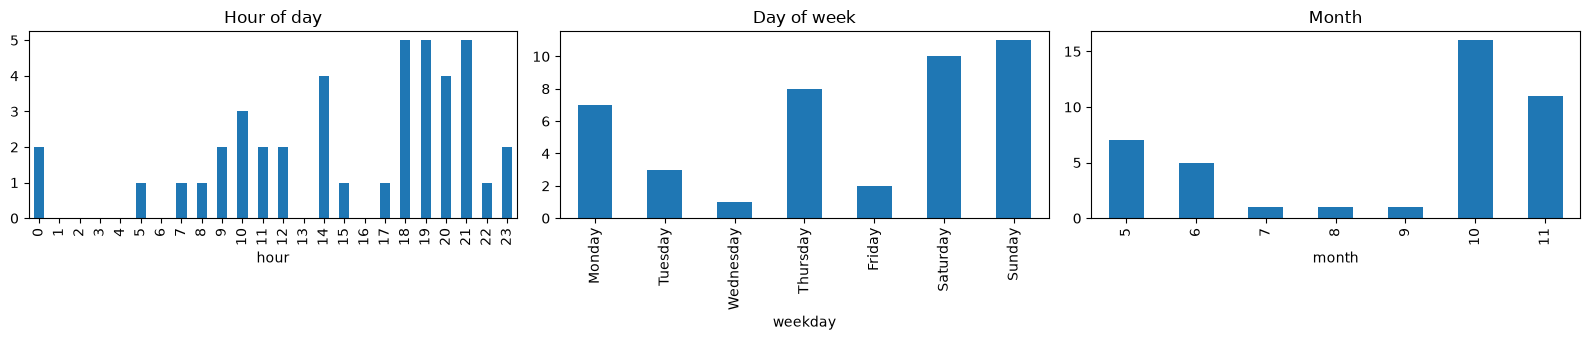

Days with any flag: 29 | days with 2+ flagged hours: 9
date
2010-05-02    2
2010-05-15    2
2010-06-05    2
2010-10-02    2
2010-10-03    2
2010-10-14    2
2010-10-18    3
2010-11-04    5
2010-11-22    2
dtype: int64
Mean kW on flagged days: 1.32 | all days: 0.958


In [25]:
a = hh[hh["n_main"] >= 2].copy()
a["weekday"] = a.index.day_name()
a["date"] = a.index.date

fig, ax = plt.subplots(1, 3, figsize=(16, 3.5))
a.groupby("hour").size().reindex(range(24), fill_value=0).plot.bar(ax=ax[0], title="Hour of day")
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
a.groupby("weekday").size().reindex(order, fill_value=0).plot.bar(ax=ax[1], title="Day of week")
a.groupby("month").size().plot.bar(ax=ax[2], title="Month")
plt.tight_layout(); plt.show()

daily = a.groupby("date").size()
print("Days with any flag:", len(daily), "| days with 2+ flagged hours:", int((daily >= 2).sum()))
print(daily[daily >= 2])

dm = hh["Actual"].resample("D").mean()
print("Mean kW on flagged days:", round(dm.reindex(pd.to_datetime(daily.index)).mean(), 3),
      "| all days:", round(dm.mean(), 3))

## 10. Save results and final figure
`anomaly_scores_hourly.csv` holds every hour; `anomalies.csv` holds the low / medium / high hours.

In [26]:
out = hh.copy()
out["Datetime"] = out.index
out = out.rename(columns={"resid": "Residual", "n_main": "methods_agree"})
out["direction"] = np.where(out["z_roll"].fillna(out["Residual"]) > 0, "higher", "lower")
out["is_anomaly"] = out["severity"].isin(["medium", "high"])
for c in ["z_anom", "iqr_anom"]:
    out[c] = out[c].fillna(False).astype(bool)
out["flagged_by"] = out[["roll_anom", "iso_anom", "resid_anom"]].apply(
    lambda r: ",".join(n for n, v in zip(["rolling_z", "isolation_forest", "residual"], r) if v), axis=1)
out["hour"] = out.index.hour
out["weekday"] = out.index.day_name()

cols = ["Datetime", "Actual", "Predicted", "Residual", "z_roll", "iso_score", "resid_rz",
        "roll_anom", "iso_anom", "resid_anom", "z_anom", "iqr_anom",
        "methods_agree", "severity", "is_anomaly", "direction", "flagged_by", "hour", "weekday"]
out = out[cols].round(4)

out.to_csv("../reports/anomaly_scores_hourly.csv", index=False)          # all 5120 hours
anom = out[out["severity"] != "none"]
anom.to_csv("../reports/anomalies.csv", index=False)                     # low + medium + high

print(len(out), len(anom), anom["severity"].value_counts().to_dict())
pd.read_csv("../reports/anomalies.csv").head()

5120 174 {'low': 132, 'medium': 26, 'high': 16}


C:\Users\94789\AppData\Local\Temp\ipykernel_17392\3157020829.py:16: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  out = out[cols].round(4)


,Datetime,Actual,Predicted,Residual,z_roll,iso_score,resid_rz,roll_anom,iso_anom,resid_anom,z_anom,iqr_anom,methods_agree,severity,is_anomaly,direction,flagged_by,hour,weekday
0,2010-04-24 21:00:00,3.1433,3.0850,0.0583,NaN,-0.0022,4.4001,False,True,False,False,False,1,low,False,higher,isolation_forest,21,Saturday
1,2010-04-25 01:00:00,2.7611,2.6693,0.0919,NaN,0.0144,6.3577,False,False,True,True,True,1,low,False,higher,residual,1,Sunday
2,2010-05-01 14:00:00,2.5501,2.4532,0.0969,NaN,-0.0047,6.6480,False,True,True,False,False,2,medium,True,higher,"isolation_forest,residual",14,Saturday
3,2010-05-02 12:00:00,3.5631,3.4560,0.1071,NaN,-0.0401,7.2437,False,True,True,False,False,2,medium,True,higher,"isolation_forest,residual",12,Sunday
4,2010-05-02 19:00:00,3.7739,3.7610,0.0129,3.8339,-0.0508,1.7513,True,True,False,False,False,2,medium,True,higher,"rolling_z,isolation_forest",19,Sunday


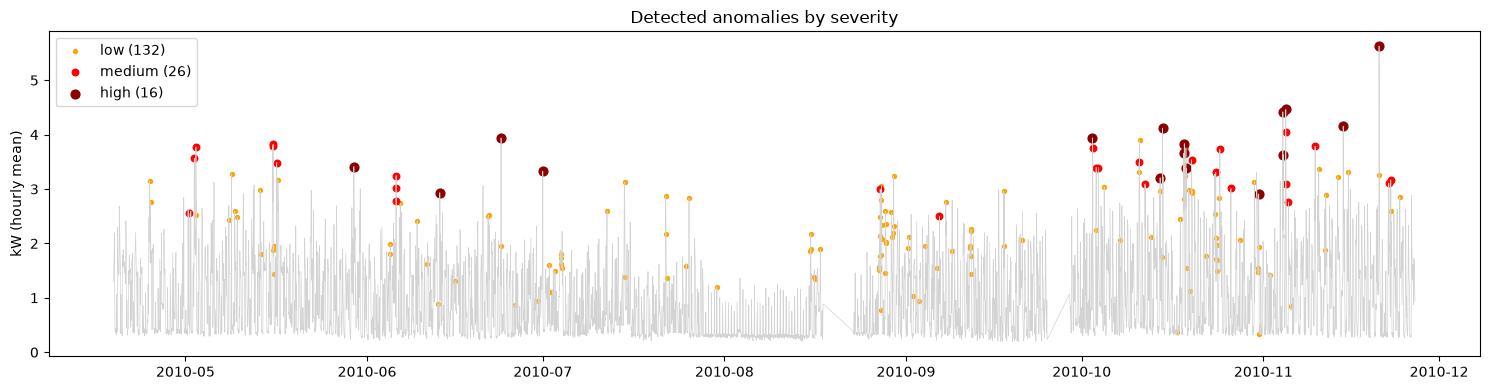

In [27]:
import os
os.makedirs("../reports/figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(hh.index, hh["Actual"], lw=0.5, color="lightgray")
for sev, c, s in [("low", "orange", 8), ("medium", "red", 22), ("high", "darkred", 40)]:
    d = hh[hh["severity"] == sev]
    ax.scatter(d.index, d["Actual"], color=c, s=s, label=f"{sev} ({len(d)})")
ax.set_ylabel("kW (hourly mean)"); ax.set_title("Detected anomalies by severity")
ax.legend(); plt.tight_layout()
plt.savefig("../reports/figures/anomaly_timeline_severity.png", dpi=150)
plt.show()